# Run SiamFC and SiamRPN++ and Compare with the Fusion Tracker

This notebook **actually runs two additional Siamese-network trackers** on the same OTB subset used by the successful Fusion experiment:

- SiamFC
- SiamRPN++ with the PySOT ResNet-50 OTB model
- Pretrained DaSiamRPN from the existing experiment
- Learned Weighted Fusion from the existing experiment

It then computes:

- Success AUC
- Precision@20
- per-sequence results
- Success and Precision curves
- ranking charts
- Fusion gains against every Siamese baseline

## Protocol

The default settings match the successful experiment:

```python
SEQUENCE_NAMES = ["Basketball", "Bolt", "Boy", "Car4"]
MAX_FRAMES = 100
```

Run this notebook in a **fresh Colab GPU runtime** using **Runtime → Run all**.


## 0. Install dependencies


In [1]:
# Do not reinstall torch or torchvision.
!pip install -q \
    gdown \
    yacs \
    colorama \
    cython \
    got10k \
    opencv-python-headless \
    pandas \
    numpy \
    matplotlib \
    tqdm


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 1. Configuration


In [3]:
from pathlib import Path
import os
import sys
import gc
import json
import math
import shutil
import subprocess
import time
import warnings

import cv2
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/MethodologyAlignedFusion"
)

OTB_ROOT = Path(
    "/content/drive/MyDrive/OTB2013_Dataset"
)

EXISTING_CACHE_ROOT = (
    PROJECT_ROOT / "cache"
)

EXISTING_FUSION_ROOT = (
    PROJECT_ROOT
    / "results"
    / "trajectories"
)

WORK_ROOT = Path(
    "/content/siamese_comparison_runtime"
)

REPOSITORY_ROOT = (
    WORK_ROOT / "repositories"
)

MODEL_ROOT = (
    "/content/drive/MyDrive/SiameseComparisonModels"
)

MODEL_ROOT = Path(MODEL_ROOT)

RESULT_ROOT = (
    PROJECT_ROOT
    / "siamese_direct_comparison"
)

TRAJECTORY_ROOT = (
    RESULT_ROOT / "trajectories"
)

FIGURE_ROOT = (
    RESULT_ROOT / "figures"
)

TABLE_ROOT = (
    RESULT_ROOT / "tables"
)

for path in [
    WORK_ROOT,
    REPOSITORY_ROOT,
    MODEL_ROOT,
    RESULT_ROOT,
    TRAJECTORY_ROOT,
    FIGURE_ROOT,
    TABLE_ROOT,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

SEQUENCE_NAMES = [
    "Basketball",
    "Bolt",
    "Boy",
    "Car4",
]

MAX_FRAMES = 100

RUN_SIAMFC = True
RUN_SIAMRPNPP = True

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", DEVICE)
print("Output:", RESULT_ROOT)


Torch: 2.11.0+cu128
CUDA: True
Device: cuda
Output: /content/drive/MyDrive/MethodologyAlignedFusion/siamese_direct_comparison


## 2. Clone the maintained tracker implementations


In [4]:
SIAMFC_REPO = (
    REPOSITORY_ROOT
    / "siamfc-pytorch"
)

PYSOT_REPO = (
    REPOSITORY_ROOT
    / "pysot"
)


def clone_repository(
    url,
    destination,
):
    if (
        destination.exists()
        and (
            destination / ".git"
        ).exists()
    ):
        print(
            "Already cloned:",
            destination.name,
        )
        return

    if destination.exists():
        shutil.rmtree(
            destination
        )

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            url,
            str(destination),
        ],
        check=True,
    )


clone_repository(
    "https://github.com/huanglianghua/siamfc-pytorch.git",
    SIAMFC_REPO,
)

clone_repository(
    "https://github.com/STVIR/pysot.git",
    PYSOT_REPO,
)

print("SiamFC repo:", SIAMFC_REPO)
print("PySOT repo:", PYSOT_REPO)


SiamFC repo: /content/siamese_comparison_runtime/repositories/siamfc-pytorch
PySOT repo: /content/siamese_comparison_runtime/repositories/pysot


## 3. Download pretrained SiamFC and SiamRPN++ models


In [5]:
SIAMFC_MODEL = (
    MODEL_ROOT
    / "siamfc_alexnet_e50.pth"
)

SIAMFC_GDRIVE_ID = (
    "1UdxuBQ1qtisoWYFZxLgMFJ9mJtGVw6n4"
)

if (
    not SIAMFC_MODEL.exists()
    or SIAMFC_MODEL.stat().st_size
    < 1_000_000
):
    print("Downloading SiamFC model...")

    gdown.download(
        id=SIAMFC_GDRIVE_ID,
        output=str(SIAMFC_MODEL),
        quiet=False,
    )

if (
    not SIAMFC_MODEL.exists()
    or SIAMFC_MODEL.stat().st_size
    < 1_000_000
):
    raise RuntimeError(
        "SiamFC model download failed."
    )

print(
    "SiamFC model:",
    SIAMFC_MODEL,
    SIAMFC_MODEL.stat().st_size,
    "bytes",
)


PYSOT_MODEL_FOLDER = (
    MODEL_ROOT
    / "siamrpn_r50_l234_dwxcorr_otb"
)

PYSOT_GDRIVE_FOLDER_URL = (
    "https://drive.google.com/drive/folders/"
    "1Cx_oHu6o0gNeH7F9zZrgevfAGdyWC4D5"
)

PYSOT_MODEL_FOLDER.mkdir(
    parents=True,
    exist_ok=True,
)

existing_pth = list(
    PYSOT_MODEL_FOLDER.rglob(
        "*.pth"
    )
)

existing_yaml = list(
    PYSOT_MODEL_FOLDER.rglob(
        "*.yaml"
    )
)

if not existing_pth:
    print(
        "Downloading the official PySOT "
        "SiamRPN++ OTB model folder..."
    )

    gdown.download_folder(
        url=PYSOT_GDRIVE_FOLDER_URL,
        output=str(
            PYSOT_MODEL_FOLDER
        ),
        quiet=False,
        use_cookies=False,
    )

PYSOT_PTH_FILES = sorted(
    PYSOT_MODEL_FOLDER.rglob(
        "*.pth"
    )
)

PYSOT_YAML_FILES = sorted(
    PYSOT_MODEL_FOLDER.rglob(
        "*.yaml"
    )
)

# The config is always available in the cloned repository even when
# the downloaded Drive folder contains only the checkpoint.
DEFAULT_PYSOT_CONFIG = (
    PYSOT_REPO
    / "experiments"
    / "siamrpn_r50_l234_dwxcorr_otb"
    / "config.yaml"
)

if PYSOT_YAML_FILES:
    PYSOT_CONFIG = (
        PYSOT_YAML_FILES[0]
    )
else:
    PYSOT_CONFIG = (
        DEFAULT_PYSOT_CONFIG
    )

if not PYSOT_PTH_FILES:
    raise RuntimeError(
        "The SiamRPN++ checkpoint was not downloaded. "
        "Open the official PySOT model folder in Drive, "
        "download model.pth, and place it under: "
        f"{PYSOT_MODEL_FOLDER}"
    )

PYSOT_MODEL = (
    PYSOT_PTH_FILES[0]
)

if not PYSOT_CONFIG.exists():
    raise FileNotFoundError(
        PYSOT_CONFIG
    )

print(
    "SiamRPN++ checkpoint:",
    PYSOT_MODEL,
)

print(
    "SiamRPN++ config:",
    PYSOT_CONFIG,
)


Downloading...
From: https://drive.google.com/uc?id=1UdxuBQ1qtisoWYFZxLgMFJ9mJtGVw6n4
To: /content/drive/MyDrive/SiameseComparisonModels/siamfc_alexnet_e50.pth
100%|██████████| 9.36M/9.36M [00:00<00:00, 26.8MB/s]
Retrieving folder contents


SiamFC model: /content/drive/MyDrive/SiameseComparisonModels/siamfc_alexnet_e50.pth 9359658 bytes
Processing file 17sRbpvAzcHAu5bligZTD9QM8XHoJVDEY model.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=17sRbpvAzcHAu5bligZTD9QM8XHoJVDEY
From (redirected): https://drive.google.com/uc?id=17sRbpvAzcHAu5bligZTD9QM8XHoJVDEY&confirm=t&uuid=40328500-66d6-4916-8b60-3b1d7f628d2f
To: /content/drive/MyDrive/SiameseComparisonModels/siamrpn_r50_l234_dwxcorr_otb/model.pth
100%|██████████| 216M/216M [00:10<00:00, 21.2MB/s]

SiamRPN++ checkpoint: /content/drive/MyDrive/SiameseComparisonModels/siamrpn_r50_l234_dwxcorr_otb/model.pth
SiamRPN++ config: /content/siamese_comparison_runtime/repositories/pysot/experiments/siamrpn_r50_l234_dwxcorr_otb/config.yaml



Download completed


## 4. Load the selected OTB sequences


In [6]:
def parse_boxes(path):
    rows = []

    with open(
        path,
        "r",
        encoding="utf-8-sig",
    ) as file:
        for raw in file:
            raw = raw.strip()

            if not raw:
                continue

            values = [
                float(value)
                for value in raw
                .replace("\t", ",")
                .replace(" ", ",")
                .split(",")
                if value != ""
            ]

            if len(values) == 4:
                rows.append(values)

            elif len(values) == 8:
                xs = values[0::2]
                ys = values[1::2]

                rows.append([
                    min(xs),
                    min(ys),
                    max(xs) - min(xs),
                    max(ys) - min(ys),
                ])

    return np.asarray(
        rows,
        dtype=np.float32,
    )


def load_sequence(
    sequence_name,
):
    sequence_directory = (
        OTB_ROOT
        / sequence_name
    )

    image_directory = (
        sequence_directory
        / "img"
    )

    images = sorted(
        list(
            image_directory.glob(
                "*.jpg"
            )
        )
        + list(
            image_directory.glob(
                "*.jpeg"
            )
        )
        + list(
            image_directory.glob(
                "*.png"
            )
        )
    )

    ground_truth_files = sorted(
        sequence_directory.glob(
            "groundtruth_rect*.txt"
        )
    )

    if not images:
        raise FileNotFoundError(
            f"No frames found for {sequence_name}"
        )

    if not ground_truth_files:
        raise FileNotFoundError(
            f"No ground truth found for {sequence_name}"
        )

    ground_truth = parse_boxes(
        ground_truth_files[0]
    )

    frame_count = min(
        len(images),
        len(ground_truth),
    )

    if MAX_FRAMES is not None:
        frame_count = min(
            frame_count,
            MAX_FRAMES,
        )

    return {
        "name": sequence_name,
        "images": [
            str(path)
            for path
            in images[:frame_count]
        ],
        "ground_truth": (
            ground_truth[:frame_count]
        ),
    }


sequences = {
    name: load_sequence(name)
    for name in SEQUENCE_NAMES
}

for name, sequence in (
    sequences.items()
):
    print(
        name,
        len(sequence["images"]),
        "frames",
    )


Basketball 100 frames
Bolt 100 frames
Boy 100 frames
Car4 100 frames


## 5. OTB Success and Precision metrics


In [7]:
def align_predictions(
    predictions,
    ground_truth,
):
    predictions = np.asarray(
        predictions,
        dtype=np.float32,
    )

    ground_truth = np.asarray(
        ground_truth,
        dtype=np.float32,
    )

    if (
        len(predictions)
        == len(ground_truth) - 1
    ):
        predictions = np.vstack([
            ground_truth[0],
            predictions,
        ])

    frame_count = min(
        len(predictions),
        len(ground_truth),
    )

    return (
        predictions[:frame_count],
        ground_truth[:frame_count],
    )


def aligned_iou(
    predictions,
    ground_truth,
):
    x1 = np.maximum(
        predictions[:, 0],
        ground_truth[:, 0],
    )

    y1 = np.maximum(
        predictions[:, 1],
        ground_truth[:, 1],
    )

    x2 = np.minimum(
        predictions[:, 0]
        + predictions[:, 2],
        ground_truth[:, 0]
        + ground_truth[:, 2],
    )

    y2 = np.minimum(
        predictions[:, 1]
        + predictions[:, 3],
        ground_truth[:, 1]
        + ground_truth[:, 3],
    )

    intersection = (
        np.maximum(0, x2 - x1)
        * np.maximum(0, y2 - y1)
    )

    prediction_area = (
        np.maximum(
            predictions[:, 2],
            0,
        )
        * np.maximum(
            predictions[:, 3],
            0,
        )
    )

    ground_truth_area = (
        np.maximum(
            ground_truth[:, 2],
            0,
        )
        * np.maximum(
            ground_truth[:, 3],
            0,
        )
    )

    union = (
        prediction_area
        + ground_truth_area
        - intersection
    )

    return np.divide(
        intersection,
        union,
        out=np.zeros_like(
            intersection
        ),
        where=union > 0,
    )


def center_errors(
    predictions,
    ground_truth,
):
    prediction_centers = np.column_stack([
        predictions[:, 0]
        + predictions[:, 2] / 2.0,
        predictions[:, 1]
        + predictions[:, 3] / 2.0,
    ])

    ground_truth_centers = np.column_stack([
        ground_truth[:, 0]
        + ground_truth[:, 2] / 2.0,
        ground_truth[:, 1]
        + ground_truth[:, 3] / 2.0,
    ])

    return np.linalg.norm(
        prediction_centers
        - ground_truth_centers,
        axis=1,
    )


def evaluate_boxes(
    predictions,
    ground_truth,
):
    predictions, ground_truth = (
        align_predictions(
            predictions,
            ground_truth,
        )
    )

    predictions = predictions[1:]
    ground_truth = ground_truth[1:]

    ious = aligned_iou(
        predictions,
        ground_truth,
    )

    errors = center_errors(
        predictions,
        ground_truth,
    )

    success_thresholds = np.linspace(
        0,
        1,
        101,
    )

    precision_thresholds = np.arange(
        0,
        51,
    )

    success_curve = np.asarray([
        (ious >= threshold).mean()
        for threshold
        in success_thresholds
    ])

    precision_curve = np.asarray([
        (errors <= threshold).mean()
        for threshold
        in precision_thresholds
    ])

    return {
        "success_auc": float(
            np.trapezoid(
                success_curve,
                success_thresholds,
            )
        ),
        "precision_20px": float(
            (errors <= 20).mean()
        ),
        "success_curve": (
            success_curve
        ),
        "precision_curve": (
            precision_curve
        ),
    }


## 6. Run SiamFC


In [8]:
siamfc_outputs = {}


def load_siamfc_tracker_class():
    if str(SIAMFC_REPO) not in sys.path:
        sys.path.insert(
            0,
            str(SIAMFC_REPO),
        )

    # PyTorch 2.6 changed torch.load's default.
    original_torch_load = (
        torch.load
    )

    def compatible_torch_load(
        *args,
        **kwargs,
    ):
        kwargs.setdefault(
            "weights_only",
            False,
        )

        return original_torch_load(
            *args,
            **kwargs,
        )

    torch.load = (
        compatible_torch_load
    )

    from siamfc import TrackerSiamFC

    return TrackerSiamFC


if RUN_SIAMFC:
    TrackerSiamFC = (
        load_siamfc_tracker_class()
    )

    siamfc_directory = (
        TRAJECTORY_ROOT
        / "SiamFC"
    )

    siamfc_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    for sequence_name, sequence in (
        sequences.items()
    ):
        output_file = (
            siamfc_directory
            / f"{sequence_name}.txt"
        )

        if output_file.exists():
            predictions = parse_boxes(
                output_file
            )

            print(
                "Loaded SiamFC:",
                sequence_name,
            )

        else:
            tracker = TrackerSiamFC(
                net_path=str(
                    SIAMFC_MODEL
                )
            )

            first_frame = cv2.imread(
                sequence[
                    "images"
                ][0]
            )

            initial_box = (
                sequence[
                    "ground_truth"
                ][0]
                .astype(np.float32)
            )

            tracker.init(
                first_frame,
                initial_box,
            )

            predictions = [
                initial_box.copy()
            ]

            for frame_path in tqdm(
                sequence["images"][1:],
                desc=(
                    f"SiamFC {sequence_name}"
                ),
                leave=False,
            ):
                frame = cv2.imread(
                    frame_path
                )

                prediction = tracker.update(
                    frame
                )

                predictions.append(
                    np.asarray(
                        prediction,
                        dtype=np.float32,
                    )
                )

            predictions = np.asarray(
                predictions,
                dtype=np.float32,
            )

            np.savetxt(
                output_file,
                predictions,
                delimiter=",",
                fmt="%.6f",
            )

            print(
                "Saved SiamFC:",
                sequence_name,
            )

            del tracker
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        siamfc_outputs[
            sequence_name
        ] = predictions
else:
    print("SiamFC disabled.")


SiamFC Basketball:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamFC: Basketball


SiamFC Bolt:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamFC: Bolt


SiamFC Boy:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamFC: Boy


SiamFC Car4:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamFC: Car4


## 7. Set up and run SiamRPN++


In [9]:
siamrpnpp_outputs = {}


def patch_pysot_for_modern_numpy():
    # Compatibility aliases required by some legacy tracking code.
    if not hasattr(
        np,
        "float",
    ):
        np.float = float

    if not hasattr(
        np,
        "int",
    ):
        np.int = int

    if not hasattr(
        np,
        "bool",
    ):
        np.bool = bool


def build_siamrpnpp_tracker():
    patch_pysot_for_modern_numpy()

    if str(PYSOT_REPO) not in sys.path:
        sys.path.insert(
            0,
            str(PYSOT_REPO),
        )

    from pysot.core.config import cfg
    from pysot.models.model_builder import (
        ModelBuilder
    )
    from pysot.tracker.tracker_builder import (
        build_tracker
    )
    from pysot.utils.model_load import (
        load_pretrain
    )

    cfg.merge_from_file(
        str(PYSOT_CONFIG)
    )

    model = ModelBuilder()

    model = load_pretrain(
        model,
        str(PYSOT_MODEL),
    )

    model = model.to(
        DEVICE
    ).eval()

    tracker = build_tracker(
        model
    )

    return tracker, model


if RUN_SIAMRPNPP:
    siamrpnpp_directory = (
        TRAJECTORY_ROOT
        / "SiamRPN++"
    )

    siamrpnpp_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    tracker, pysot_model = (
        build_siamrpnpp_tracker()
    )

    for sequence_name, sequence in (
        sequences.items()
    ):
        output_file = (
            siamrpnpp_directory
            / f"{sequence_name}.txt"
        )

        if output_file.exists():
            predictions = parse_boxes(
                output_file
            )

            print(
                "Loaded SiamRPN++:",
                sequence_name,
            )

        else:
            initial_box = (
                sequence[
                    "ground_truth"
                ][0]
                .astype(np.float32)
                .tolist()
            )

            first_frame = cv2.imread(
                sequence[
                    "images"
                ][0]
            )

            tracker.init(
                first_frame,
                initial_box,
            )

            predictions = [
                np.asarray(
                    initial_box,
                    dtype=np.float32,
                )
            ]

            for frame_path in tqdm(
                sequence["images"][1:],
                desc=(
                    f"SiamRPN++ "
                    f"{sequence_name}"
                ),
                leave=False,
            ):
                frame = cv2.imread(
                    frame_path
                )

                output = tracker.track(
                    frame
                )

                prediction = np.asarray(
                    output["bbox"],
                    dtype=np.float32,
                )

                predictions.append(
                    prediction
                )

            predictions = np.asarray(
                predictions,
                dtype=np.float32,
            )

            np.savetxt(
                output_file,
                predictions,
                delimiter=",",
                fmt="%.6f",
            )

            print(
                "Saved SiamRPN++:",
                sequence_name,
            )

        siamrpnpp_outputs[
            sequence_name
        ] = predictions

    del tracker
    del pysot_model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("SiamRPN++ disabled.")


SiamRPN++ Basketball:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamRPN++: Basketball


SiamRPN++ Bolt:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamRPN++: Bolt


SiamRPN++ Boy:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamRPN++: Boy


SiamRPN++ Car4:   0%|          | 0/99 [00:00<?, ?it/s]

Saved SiamRPN++: Car4


## 8. Load the existing DaSiamRPN and Fusion outputs


In [10]:
def find_existing_file(
    candidates,
):
    for candidate in candidates:
        candidate = Path(candidate)

        if candidate.exists():
            return candidate

    return None


existing_outputs = {
    "Pretrained DaSiamRPN": {},
    "Learned Weighted Fusion": {},
}

for sequence_name in SEQUENCE_NAMES:
    branch_cache = (
        EXISTING_CACHE_ROOT
        / f"{sequence_name}_branches.npz"
    )

    if not branch_cache.exists():
        raise FileNotFoundError(
            branch_cache
        )

    cached = np.load(
        branch_cache
    )

    if "siam_boxes" not in cached.files:
        raise KeyError(
            f"siam_boxes missing from "
            f"{branch_cache}"
        )

    existing_outputs[
        "Pretrained DaSiamRPN"
    ][sequence_name] = (
        cached["siam_boxes"]
    )

    fusion_file = find_existing_file([
        EXISTING_FUSION_ROOT
        / f"{sequence_name}.txt",

        EXISTING_FUSION_ROOT
        / "Learned_Weighted_Fusion"
        / f"{sequence_name}.txt",
    ])

    if fusion_file is None:
        raise FileNotFoundError(
            f"Missing Fusion trajectory "
            f"for {sequence_name}"
        )

    existing_outputs[
        "Learned Weighted Fusion"
    ][sequence_name] = (
        parse_boxes(
            fusion_file
        )
    )

print(
    "Existing Fusion and DaSiamRPN "
    "outputs loaded."
)


Existing Fusion and DaSiamRPN outputs loaded.


## 9. Evaluate every Siamese tracker


In [11]:
all_outputs = {
    **existing_outputs,
}

if siamfc_outputs:
    all_outputs[
        "SiamFC"
    ] = siamfc_outputs

if siamrpnpp_outputs:
    all_outputs[
        "SiamRPN++"
    ] = siamrpnpp_outputs

rows = []
curves = {}

for tracker_name, tracker_sequences in (
    all_outputs.items()
):
    curves[tracker_name] = {
        "success": [],
        "precision": [],
    }

    for sequence_name in SEQUENCE_NAMES:
        result = evaluate_boxes(
            tracker_sequences[
                sequence_name
            ],
            sequences[
                sequence_name
            ]["ground_truth"],
        )

        rows.append({
            "tracker": tracker_name,
            "sequence": sequence_name,
            "success_auc": (
                result[
                    "success_auc"
                ]
            ),
            "precision_20px": (
                result[
                    "precision_20px"
                ]
            ),
        })

        curves[
            tracker_name
        ]["success"].append(
            result[
                "success_curve"
            ]
        )

        curves[
            tracker_name
        ]["precision"].append(
            result[
                "precision_curve"
            ]
        )


per_sequence_df = pd.DataFrame(
    rows
)

summary_df = (
    per_sequence_df
    .groupby(
        "tracker",
        as_index=False,
    )
    [[
        "success_auc",
        "precision_20px",
    ]]
    .mean()
    .sort_values(
        [
            "success_auc",
            "precision_20px",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

summary_df[
    "rank_success"
] = (
    summary_df[
        "success_auc"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

summary_df[
    "rank_precision"
] = (
    summary_df[
        "precision_20px"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

display(summary_df)
display(per_sequence_df)

summary_df.to_csv(
    TABLE_ROOT
    / "siamese_tracker_summary.csv",
    index=False,
)

per_sequence_df.to_csv(
    TABLE_ROOT
    / "siamese_tracker_per_sequence.csv",
    index=False,
)


,tracker,success_auc,precision_20px,rank_success,rank_precision
0,SiamRPN++,0.782045,1.000000,1,1
1,Learned Weighted Fusion,0.765442,0.997475,2,2
2,Pretrained DaSiamRPN,0.748687,0.989899,3,3
3,SiamFC,0.625303,0.787879,4,4


,tracker,sequence,success_auc,precision_20px
0,Pretrained DaSiamRPN,Basketball,0.597525,0.959596
1,Pretrained DaSiamRPN,Bolt,0.733788,1.000000
2,Pretrained DaSiamRPN,Boy,0.837525,1.000000
3,Pretrained DaSiamRPN,Car4,0.825909,1.000000
4,Learned Weighted Fusion,Basketball,0.599495,0.989899
5,Learned Weighted Fusion,Bolt,0.755909,1.000000
6,Learned Weighted Fusion,Boy,0.851869,1.000000
7,Learned Weighted Fusion,Car4,0.854495,1.000000
8,SiamFC,Basketball,0.648232,0.979798
9,SiamFC,Bolt,0.117323,0.171717


## 10. Success plot


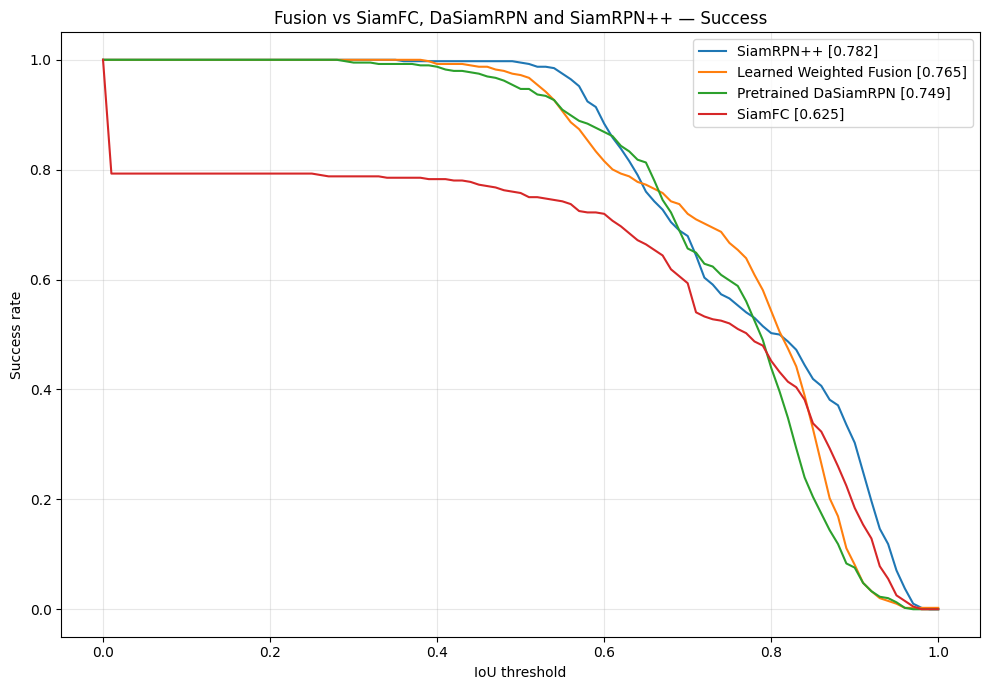

Saved: /content/drive/MyDrive/MethodologyAlignedFusion/siamese_direct_comparison/figures/direct_siamese_success.png


In [12]:
success_thresholds = np.linspace(
    0,
    1,
    101,
)

plt.figure(
    figsize=(10, 7)
)

for tracker_name in summary_df[
    "tracker"
]:
    mean_curve = np.mean(
        curves[
            tracker_name
        ]["success"],
        axis=0,
    )

    auc = np.trapezoid(
        mean_curve,
        success_thresholds,
    )

    plt.plot(
        success_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{auc:.3f}]"
        ),
    )

plt.xlabel("IoU threshold")
plt.ylabel("Success rate")
plt.title(
    "Fusion vs SiamFC, DaSiamRPN "
    "and SiamRPN++ — Success"
)
plt.grid(
    True,
    alpha=0.3,
)
plt.legend()
plt.tight_layout()

success_path = (
    FIGURE_ROOT
    / "direct_siamese_success.png"
)

plt.savefig(
    success_path,
    dpi=300,
)

plt.show()

print("Saved:", success_path)


## 11. Precision plot


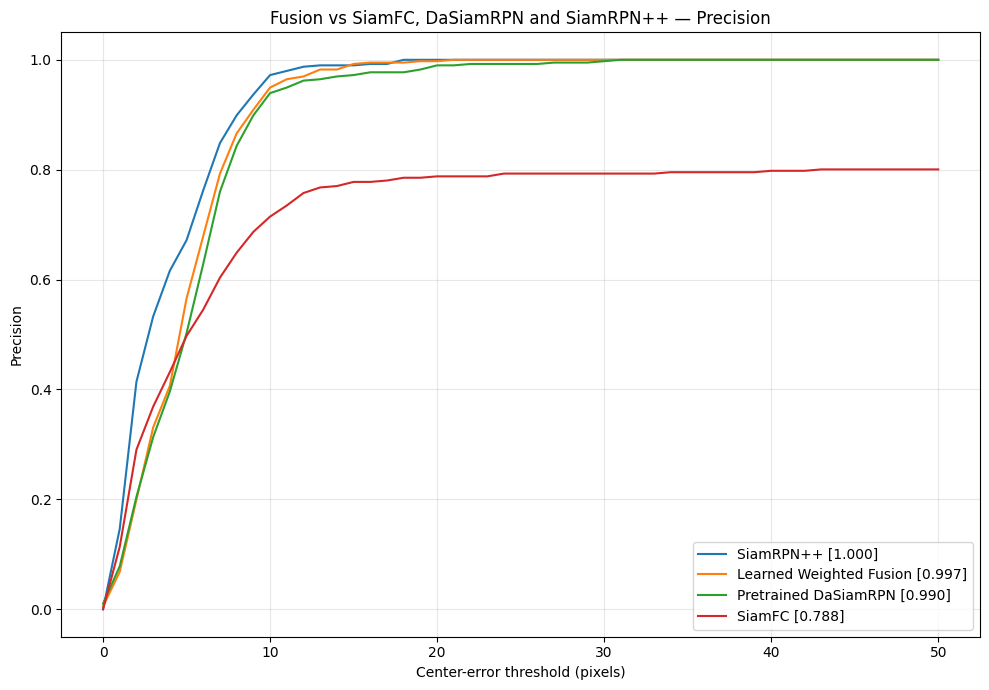

Saved: /content/drive/MyDrive/MethodologyAlignedFusion/siamese_direct_comparison/figures/direct_siamese_precision.png


In [13]:
precision_thresholds = np.arange(
    0,
    51,
)

plt.figure(
    figsize=(10, 7)
)

for tracker_name in summary_df[
    "tracker"
]:
    mean_curve = np.mean(
        curves[
            tracker_name
        ]["precision"],
        axis=0,
    )

    plt.plot(
        precision_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{mean_curve[20]:.3f}]"
        ),
    )

plt.xlabel(
    "Center-error threshold (pixels)"
)
plt.ylabel("Precision")
plt.title(
    "Fusion vs SiamFC, DaSiamRPN "
    "and SiamRPN++ — Precision"
)
plt.grid(
    True,
    alpha=0.3,
)
plt.legend()
plt.tight_layout()

precision_path = (
    FIGURE_ROOT
    / "direct_siamese_precision.png"
)

plt.savefig(
    precision_path,
    dpi=300,
)

plt.show()

print("Saved:", precision_path)


## 12. Ranking charts


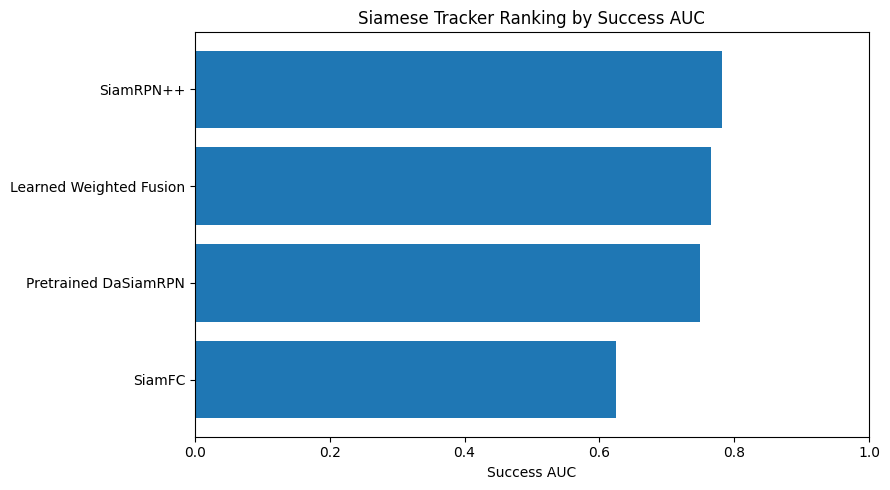

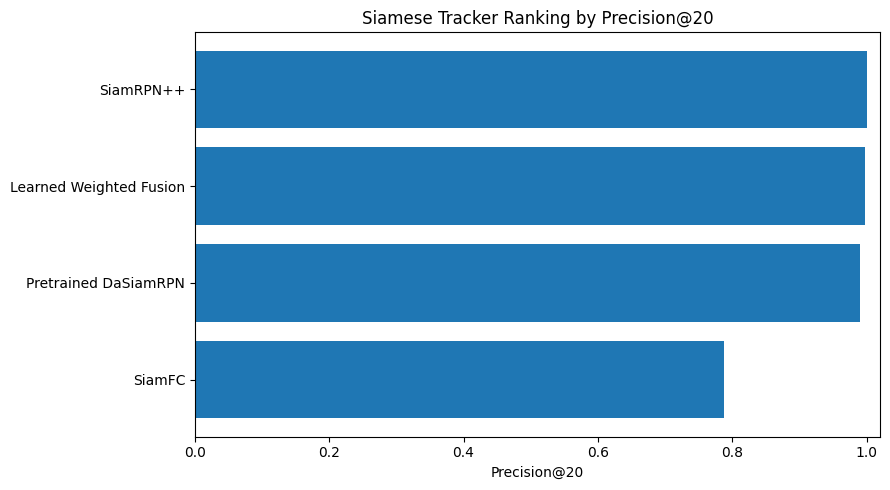

In [14]:
ranked_success = (
    summary_df
    .sort_values(
        "success_auc",
        ascending=True,
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    ranked_success[
        "tracker"
    ],
    ranked_success[
        "success_auc"
    ],
)

plt.xlabel("Success AUC")
plt.title(
    "Siamese Tracker Ranking "
    "by Success AUC"
)
plt.xlim(0, 1)
plt.tight_layout()

success_rank_path = (
    FIGURE_ROOT
    / "direct_siamese_success_ranking.png"
)

plt.savefig(
    success_rank_path,
    dpi=300,
)

plt.show()


ranked_precision = (
    summary_df
    .sort_values(
        "precision_20px",
        ascending=True,
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    ranked_precision[
        "tracker"
    ],
    ranked_precision[
        "precision_20px"
    ],
)

plt.xlabel("Precision@20")
plt.title(
    "Siamese Tracker Ranking "
    "by Precision@20"
)
plt.xlim(0, 1.02)
plt.tight_layout()

precision_rank_path = (
    FIGURE_ROOT
    / "direct_siamese_precision_ranking.png"
)

plt.savefig(
    precision_rank_path,
    dpi=300,
)

plt.show()


## 13. Fusion gains against every Siamese tracker


In [15]:
fusion_row = summary_df.loc[
    summary_df[
        "tracker"
    ] == "Learned Weighted Fusion"
].iloc[0]

gain_df = summary_df.loc[
    summary_df[
        "tracker"
    ] != "Learned Weighted Fusion"
].copy()

gain_df[
    "fusion_success_gain"
] = (
    float(
        fusion_row[
            "success_auc"
        ]
    )
    - gain_df[
        "success_auc"
    ]
)

gain_df[
    "fusion_precision_gain"
] = (
    float(
        fusion_row[
            "precision_20px"
        ]
    )
    - gain_df[
        "precision_20px"
    ]
)

gain_df[
    "fusion_better_success"
] = (
    gain_df[
        "fusion_success_gain"
    ] > 0
)

gain_df[
    "fusion_better_precision"
] = (
    gain_df[
        "fusion_precision_gain"
    ] > 0
)

gain_df = gain_df.sort_values(
    "success_auc",
    ascending=False,
)

display(gain_df)

gain_df.to_csv(
    TABLE_ROOT
    / "fusion_gain_vs_siamese_trackers.csv",
    index=False,
)


,tracker,success_auc,precision_20px,rank_success,rank_precision,fusion_success_gain,fusion_precision_gain,fusion_better_success,fusion_better_precision
0,SiamRPN++,0.782045,1.000000,1,1,-0.016604,-0.002525,False,False
2,Pretrained DaSiamRPN,0.748687,0.989899,3,3,0.016755,0.007576,True,True
3,SiamFC,0.625303,0.787879,4,4,0.140139,0.209596,True,True


## 14. LaTeX and paper-ready results


In [16]:
latex_df = summary_df[
    [
        "tracker",
        "success_auc",
        "precision_20px",
    ]
].copy()

latex_df[
    "success_auc"
] = latex_df[
    "success_auc"
].map(
    lambda value: f"{value:.3f}"
)

latex_df[
    "precision_20px"
] = latex_df[
    "precision_20px"
].map(
    lambda value: f"{value:.3f}"
)

latex_table = latex_df.to_latex(
    index=False,
    header=[
        "Tracker",
        "Success AUC",
        "Precision@20",
    ],
    caption=(
        "Same-protocol comparison with "
        "Siamese-network trackers."
    ),
    label=(
        "tab:direct_siamese_comparison"
    ),
)

print(latex_table)

(
    TABLE_ROOT
    / "direct_siamese_comparison.tex"
).write_text(
    latex_table,
    encoding="utf-8",
)


strongest_non_fusion = (
    summary_df.loc[
        summary_df[
            "tracker"
        ] != "Learned Weighted Fusion"
    ]
    .sort_values(
        "success_auc",
        ascending=False,
    )
    .iloc[0]
)

result_text = f'''
## Same-protocol Siamese tracker comparison

The Learned Weighted Fusion framework achieved:

- Success AUC: {fusion_row["success_auc"]:.3f}
- Precision@20: {fusion_row["precision_20px"]:.3f}

The strongest evaluated non-fusion Siamese tracker was
{strongest_non_fusion["tracker"]}, which achieved:

- Success AUC: {strongest_non_fusion["success_auc"]:.3f}
- Precision@20: {strongest_non_fusion["precision_20px"]:.3f}

Fusion changed Success AUC by
{fusion_row["success_auc"] - strongest_non_fusion["success_auc"]:+.3f}
and Precision@20 by
{fusion_row["precision_20px"] - strongest_non_fusion["precision_20px"]:+.3f}.

All trackers were evaluated on the same {len(SEQUENCE_NAMES)} OTB sequences,
using at most {MAX_FRAMES} frames per sequence.
'''

print(result_text)

(
    RESULT_ROOT
    / "paper_ready_siamese_results.md"
).write_text(
    result_text,
    encoding="utf-8",
)


\begin{table}
\caption{Same-protocol comparison with Siamese-network trackers.}
\label{tab:direct_siamese_comparison}
\begin{tabular}{lll}
\toprule
Tracker & Success AUC & Precision@20 \\
\midrule
SiamRPN++ & 0.782 & 1.000 \\
Learned Weighted Fusion & 0.765 & 0.997 \\
Pretrained DaSiamRPN & 0.749 & 0.990 \\
SiamFC & 0.625 & 0.788 \\
\bottomrule
\end{tabular}
\end{table}


## Same-protocol Siamese tracker comparison

The Learned Weighted Fusion framework achieved:

- Success AUC: 0.765
- Precision@20: 0.997

The strongest evaluated non-fusion Siamese tracker was
SiamRPN++, which achieved:

- Success AUC: 0.782
- Precision@20: 1.000

Fusion changed Success AUC by
-0.017
and Precision@20 by
-0.003.

All trackers were evaluated on the same 4 OTB sequences,
using at most 100 frames per sequence.



428

# Full benchmark later

After the four-sequence run works, change:

```python
MAX_FRAMES = None
```

and expand `SEQUENCE_NAMES` to all available OTB2013 sequences.

The direct comparison should be reported separately from published leaderboard values because this notebook uses a controlled subset protocol.
